# CSI Based WiFi Setting


### By Seth Kantz and Matthew Delafield

The goal for this project will be to detect motion in a room given CSI data from a raspberry pi 4b.  Structure shown here is for use with CSI Dataset available via IEEE Dataport https://ieee-dataport.org/documents/csi-dataset-wifi-based-human-detection .  Place in repo and rename 'CSV Files' to 'CSV_Files' for best use.

This data is captured from a 20MHz channel via Nexmon tool, see here for setup and use. https://github.com/seemoo-lab/nexmon_csi?tab=readme-ov-file#getting-started

The imaginary data from each channel is used and fed into the CNN for better understanding, the neural network will see how these values change over time vs a known "no motion" and a known "motion" to classify as one of those two categories


### Imports
Import necessary files, note that cuda driver failures are expected if running on a laptop or a machine without GPU.  The processing should behave just find and these issues can be ignored.  If other errors occur you need to ensure that imports are installed correctly via pip

In [31]:
from pathlib import Path
import numpy as np
import re
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


###

### Set Variables / Paths

Set up high level logic for subcarriers, expected file / folder layout for data to be read in.

In [32]:
#
# sets path used for training the data, room 4 for basis now
ROOT = Path("data/hf_dataset/pcap_csvs/split_csv")

# key=testname, val= (static_folder, dynamic_folder)
test_dict = {
    "RoomS_LocA_ch157_40MHz": ("40_idle", "40_walking"),
    "RoomS_LocA_ch157_80MHz": ("80_idle", "80_walking"),
    "RoomS_LocB_ch157_40MHz": ("40_idle_blocked", "40_walking_blocked"),
    "RoomS_LocB_ch157_80MHz": ("80_idle_blocked", "80_walking_blocked"),
}

STATIC_MAG   = ROOT / "40_idle"
DYNAMIC_MAG  = ROOT / "40_walking"

#STATIC_MAG   = ROOT / "Static_noperson_channel_11_20mhz" / "csi_magnitude_data"
#DYNAMIC_MAG  = ROOT / "Dynamic_1_person_ch11_20mhz"      / "csi_magnitude_data"

STATIC_CPLX  = ROOT / "Static_noperson_channel_11_20mhz" / "csi_complex_data"
DYNAMIC_CPLX = ROOT / "Dynamic_1_person_ch11_20mhz"      / "csi_complex_data"

# sets number of subcarriers used (49 for 20MHz)
SUBCARRIERS_20MHz = 49
SUBCARRIERS_40MHz = 128
SUBCARRIERS_80MHz = 256


# sets number of rows to be fed into neural net
L = 1024  

base = ROOT


### Helper Functions
Functions that make life easier later on for reading data, separating files, loading, etc

In [33]:

def gather_paths(static_path, dynamic_path):
    ''' Return paths and labels for static + dynamic files'''
    static_files  = sorted(static_path.glob("*.csv"))
    dynamic_files = sorted(dynamic_path.glob("*.csv"))

    paths = static_files + dynamic_files
    labels = np.array([0]*len(static_files) + [1]*len(dynamic_files), dtype=np.int32)
    return paths, labels

def load_mag_csv(path, num_subcarriers, L=L):
    # function to load in the magnitude data 
    
    df = pd.read_csv(path)
    # (T, 49)
    X = df.to_numpy(dtype=np.float32)          
    X = np.log1p(np.abs(X))                  
    T, S = X.shape

    # sanity check here to make sure we ahve correct subcarrier len
    assert S == num_subcarriers, f"Expected {num_subcarriers} cols, got {S}"

    if T >= L:
        start = np.random.randint(0, T - L + 1)
        X = X[start:start+L]
    else:
        X = np.pad(X, ((0, L-T), (0,0)), mode="constant")

    # normalize data read in
    X = (X - X.mean()) / (X.std() + 1e-6)
    return X[..., None]  # (L, 49, 1)

def recording_id(p: Path):
    # grabs naming for csi_YYYYMMDD_HHMMSS
    m = re.search(r"(csi_\d{8}_\d{6})", p.name)
    return m.group(1) if m else p.stem

def batch_generator(paths, labels, num_subcarriers, batch_size=8):
    # modified from what we learned in neural nets, lets us read in random files from the inputted paths that mean our criteria
    paths = np.array(paths)
    labels = np.array(labels)
    n = len(paths)
    while True:
        idx = np.random.permutation(n)
        for i in range(0, n, batch_size):
            b = idx[i:i+batch_size]
            Xb = np.stack([load_mag_csv(paths[j],num_subcarriers) for j in b])
            yb = labels[b]

            # yield lets us update without losing status of vars
            yield Xb, yb

    

### Read in Data


This step will read in the training data and begin to split filepaths into the necessary groups using groupshufflesplit.  Two calls are needed to separate into three distinct buckets.

Currently using 60/25/15 train/val/test split

In [34]:

test_key = "RoomS_LocA_ch157_80MHz"

if "20MHz" in test_key:
    subcarriers = SUBCARRIERS_20MHz
elif "40MHz" in test_key:
    subcarriers = SUBCARRIERS_40MHz
elif "80MHz" in test_key:
    subcarriers = SUBCARRIERS_80MHz
else:
    print("ERR INVALID SUBCARRIERS")
    
static_folder, dynamic_folder = test_dict[test_key]
static_files = ROOT / static_folder
dynamic_files = ROOT / dynamic_folder

paths, labels = gather_paths(static_files,dynamic_files)
paths = np.array(paths)
groups = np.array([recording_id(p) for p in paths])

# Separate 60% for training, 40% for test/val
gss = GroupShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
trainval_idx, test_idx = next(gss.split(paths, labels, groups=groups))

# Separate 15% (0.375*0.4) for training, 25% for validation
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.375, random_state=43)
train_sub_idx, val_sub_idx = next(
    gss2.split(
        paths[trainval_idx],
        labels[trainval_idx],
        groups=groups[trainval_idx]
    )
)

# Map subset indices back to original dataset indices
train_idx = trainval_idx[train_sub_idx]
val_idx   = trainval_idx[val_sub_idx]

train_paths = paths[train_idx]
val_paths   = paths[val_idx]
test_paths  = paths[test_idx]

train_y = labels[train_idx]
val_y   = labels[val_idx]
test_y  = labels[test_idx]

print(len(train_paths))
print(len(val_paths))
print(len(test_paths))
print("Train ∩ Val:", len(set(train_paths) & set(val_paths)))
print("Train ∩ Test:", len(set(train_paths) & set(test_paths)))
print("Val ∩ Test:", len(set(val_paths) & set(test_paths)))

31
20
35
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


### Set Train / Test / Validation Split

Uses above filepaths and breaks up dataset read in so we can properly validate neural net

In [35]:
#
batch_size = 8
train_gen = batch_generator(train_paths, train_y, subcarriers, batch_size)
val_gen   = batch_generator(val_paths, val_y, subcarriers, batch_size)
test_gen   = batch_generator(test_paths, test_y, subcarriers, batch_size)




NameError: name 'subcarrier' is not defined

### Configure 2D Convolutional neural net

Basic structure for neural net and print.  Chosen based on what we learned from neural networks course.  @todo tweak as test results come in, verify this behaving as expected.

CUDA error here is expected bc of above note.


In [20]:
inp = layers.Input(shape=(L, subcarriers, 1))
x = layers.Conv2D(16, (7,3), padding="same", activation="relu")(inp)
x = layers.MaxPool2D((4,2))(x)
x = layers.Conv2D(32, (7,3), padding="same", activation="relu")(x)
x = layers.MaxPool2D((4,2))(x)
x = layers.Conv2D(64, (5,3), padding="same", activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inp, out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)


model.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1024, 128, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 1024, 128, 16)  │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 256, 64, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 64, 32)    │        10,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 32, 64)     │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,985 (164.00 KB)

 Trainable params: 41,985 (164.00 KB)

 Non-trainable params: 0 (0.00 B)

### Train Model

Train data, note that this can take some time to run, but early stopping should prevent overfitting / overly long tests.

In [21]:
#
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", patience=8, mode="max", restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", factor=0.5, patience=3, mode="max", min_lr=1e-6),
]

history = model.fit(
    train_gen,
    steps_per_epoch=max(1, len(train_paths)//batch_size),
    validation_data=val_gen,
    validation_steps=max(1, len(val_paths)//batch_size),
    epochs=60,
    callbacks=callbacks
)

Epoch 1/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 702ms/step - accuracy: 0.6250 - auc: 0.6821 - loss: 0.6693 - val_accuracy: 0.5000 - val_auc: 0.9062 - val_loss: 0.7117 - learning_rate: 0.0010
Epoch 2/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - accuracy: 0.5652 - auc: 0.4583 - loss: 0.7273 - val_accuracy: 0.5000 - val_auc: 0.9219 - val_loss: 0.6947 - learning_rate: 0.0010
Epoch 3/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 412ms/step - accuracy: 0.4348 - auc: 0.7063 - loss: 0.7177 - val_accuracy: 0.5000 - val_auc: 1.0000 - val_loss: 0.6721 - learning_rate: 0.0010
Epoch 4/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 393ms/step - accuracy: 0.4348 - auc: 0.5269 - loss: 0.6963 - val_accuracy: 0.5000 - val_auc: 1.0000 - val_loss: 0.6761 - learning_rate: 0.0010
Epoch 5/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 405ms/step - accuracy: 0.4167 - auc: 0.5524 - loss: 0.6850 - val_accuracy: 0.6250 - val_auc: 1.0000 - val_loss: 0.6571 - learning_rate: 0.0010
Epoch 6/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 409ms/step - accuracy: 0.6522 - auc: 0.8000 - loss:

### Evaluate Model

Basic evaluation printed here.

In [22]:
#
steps = int(np.ceil(len(test_paths) / batch_size))

print(model.evaluate(test_gen, steps=steps))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 0.6000 - auc: 1.0000 - loss: 0.6675
[0.6675057411193848, 0.6000000238418579, 1.0]


### Calculate errors / performance


### Graph Data

Helper graphs to better understand how it is behaving.

will add more error / performance sanity checks here later if needed as data comes in.

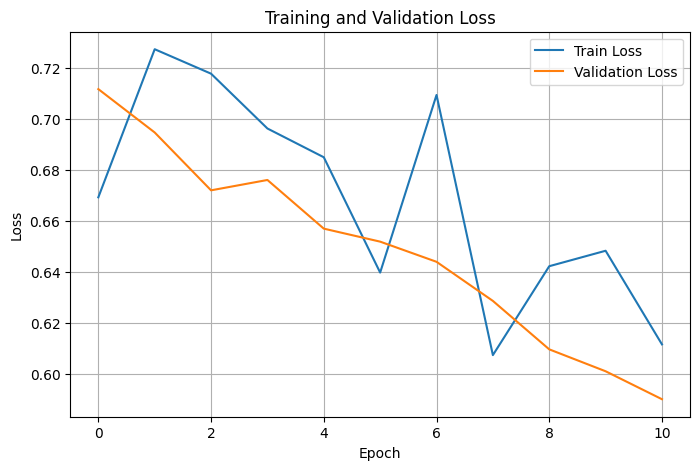

In [23]:

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

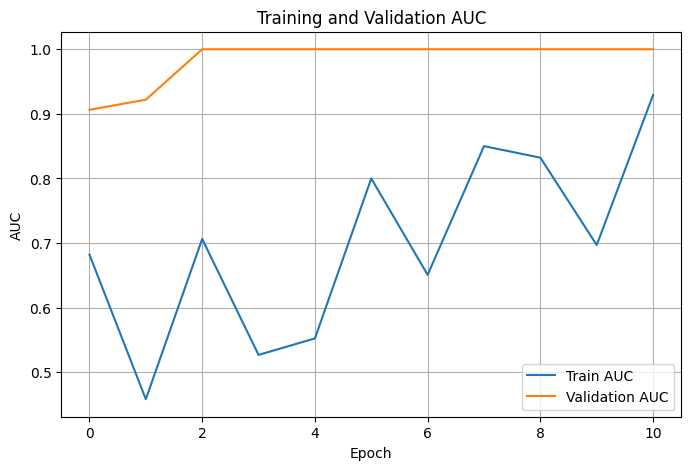

In [24]:
plt.figure(figsize=(8,5))
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Training and Validation AUC')
plt.legend()
plt.grid(True)
plt.show()